<a href="https://colab.research.google.com/github/AYCDJ/Water-level-forecasting-LSTM-/blob/main/RF_Tide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import numpy as np
from scipy import stats, signal
from IPython.display import display,Latex
from windrose import WindroseAxes
from datetime import timedelta
import math
import pickle
import joblib
from tabulate import tabulate
import WLPreprocessing as WLP

In [ ]:
!pip install windrose

In [ ]:
def add_96hr_water_levels(df, how_far=96):
    for h in range(13,how_far+1):
        df['-'+str(h)+'hr Hourly Water Level'] = [df['1hr Water Level'].get(date- timedelta(hours=h), None)for date in df.index]
    return df.copy()

def add_wind_force(df, how_far=24):
    for h in range(13,how_far+1):
        df[str(h)+'hr Alongshore Wind Force'] = df['Alongshore Wind Force'].rolling(str(h)+'h').sum()
        df[str(h)+'hr Alongshore sq Wind Force'] = df['Alongshore sq Wind Force'].rolling(str(h)+'h').sum()
        df[str(h)+'hr Onshore Wind Force'] = df['Onshore Wind Force'].rolling(str(h)+'h').sum()
        df[str(h)+'hr Onshore sq Wind Force'] = df['Onshore sq Wind Force'].rolling(str(h)+'h').sum()
    for h in range(1,how_far+1):
        df[str(h)+'hr Avg Alongshore Wind Force'] = df['Alongshore Wind Force'].rolling(str(h)+'h').mean()
        df[str(h)+'hr Avg Alongshore sq Wind Force'] = df['Alongshore sq Wind Force'].rolling(str(h)+'h').mean()
        df[str(h)+'hr Avg Onshore Wind Force'] = df['Onshore Wind Force'].rolling(str(h)+'h').mean()
        df[str(h)+'hr Avg Onshore sq Wind Force'] = df['Onshore sq Wind Force'].rolling(str(h)+'h').mean()
    return df.copy()

def add_predictions(df, how_far=23, rate='1h'):  # for now the 24 hr done already
    for h in range(1,how_far+1):
        df['Predicted Wind Speed in '+str(h)+'hr'] = [df['Wind Speed'].get(date+ timedelta(hours=h), None)for date in df.index]
        df['Predicted Wind Dirrection in '+str(h)+'hr'] = [df['Wind Direction'].get(date+ timedelta(hours=h), None)for date in df.index]
        df['Predicted Onshore Wind Force in '+str(h)+'hr'] = df['Predicted Wind Speed in '+str(h)+'hr']*np.cos(np.radians(df['Predicted Wind Dirrection in '+str(h)+'hr']-115))
        df['Predicted Onshore sq Wind Force in '+str(h)+'hr'] = df['Predicted Wind Speed in '+str(h)+'hr']*df['Predicted Wind Speed in '+str(h)+'hr']*np.cos(np.radians(df['Predicted Wind Dirrection in '+str(h)+'hr']-115))
    return df.copy()

def add_all_new_features(df):
    print('eh')

In [ ]:
def find_best_features_r2(df, test_df, verbose=0, title='', delta=.001, max_features=15):
    if (title != ''): display(HTML('<h2>'+title+'</h2>'))
    all_features = list(df.keys())
    all_features.remove('Water Level')
    all_features.remove('Target')
    best_features = ['Water Level']
    bestr2 = .1
    AllResults = []
    for nf in range(max_features):
        lastbestr2=bestr2
        bestf = ''
        for f in all_features:
            features = best_features+[f]
            curresults = run_a_regressor3(features, df, test_df)
#             print('testing', curresults)
            if curresults[3] > bestr2:
                bestf = f
                bestr2 = curresults[3]
                bestresults=curresults
#                 AllResults.append([nf]+curresults)
            if verbose > 0:
                print(curresults)
    #         else:
    #             print(curresults[3])
        if bestf != '':
    #         print('adding', bestf)

            improvement = (bestr2-lastbestr2)/lastbestr2
            AllResults.append([nf, improvement]+bestresults)
            best_features.append(bestf)
            all_features.remove(bestf)
            if improvement < delta: break   # improvement insignificant

        else:
    #         print('done adding')
            break  # adding a feature didn't help so stop adding.

    display(HTML(tabulate(AllResults, headers=['cnt','imrovement','features','MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'],
                          tablefmt="html")))

def find_best_features_MSE_r2(df, test_df, verbose=0, title='', delta=.001, max_features=15):
    if (title != ''): display(HTML('<h2>'+title+'</h2>'))
    all_features = list(df.keys())
    all_features.remove('Water Level')
    all_features.remove('Target')
    best_features = ['Water Level']
    bestMSE = 600
    bestr2 = .1
    AllResults = []
    for nf in range(max_features):
        bestf = ''
        lastbestr2 = bestr2
        lastbestMSE = bestMSE
        for f in all_features:
            features = best_features+[f]
            curresults = run_a_regressor3(features, df, test_df)
            if curresults[3] > bestr2:
                bestf = f
                bestr2 = curresults[3]
                bestresults=curresults
#                 AllResults.append([nf]+curresults)
                if curresults[1] < bestMSE:
                    bestMSE = curresults[1]
                if verbose > 0:
                    print(curresults)

            if curresults[1] < bestMSE:
                bestf = f
                bestMSE = curresults[1]
                if curresults[3] > bestr2:
                    bestr2 = curresults[3]
#                 AllResults.append([nf]+curresults)
                if verbose > 0:
                    print(curresults)
    #         else:
    #             print(curresults[3])
        if bestf != '':
    #         print('adding', bestf)
            improvement1 = (lastbestMSE-bestMSE)/lastbestMSE
            improvement2 = (bestr2-lastbestr2)/lastbestr2
            improvement = max(improvement1, improvement2)
            AllResults.append([nf, improvement]+bestresults)
            best_features.append(bestf)
            all_features.remove(bestf)
            bestf = ''
            if improvement < delta: break   # improvement insignificant


        else:
    #         print('done adding')
            break  # adding a feature didn't help so stop adding.

    display(HTML(tabulate(AllResults, headers=['num', 'improvement','features','MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'],
                          tablefmt="html")))


def find_best_features_MSE(df, test_df, verbose=0, title='', delta=.001, max_features=15):
    if (title != ''): display(HTML('<h2>'+title+'</h2>'))
    all_features = list(df.keys())
    all_features.remove('Water Level')
    all_features.remove('Target')
    best_features = ['Water Level']
    bestMSE = 600
    AllResults = []
    for nf in range(max_features):
        bestf = ''
        lastbestMSE = bestMSE

        for f in all_features:
            features = best_features+[f]
            curresults = run_a_regressor3(features, df, test_df)
            if curresults[1] < bestMSE:
                bestf = f
                bestMSE = curresults[1]
                bestresults=curresults
                if verbose > 0:
                    print('f:', f, ' regrossor results', curresults[1], ' bestMSE:',bestMSE)
        if bestf != '':
            improvement = (lastbestMSE-bestMSE)/lastbestMSE
            if verbose > 0: print('adding ', bestf, ' lastbestMSE:', lastbestMSE, ' bestMSE:', bestMSE, ' improvement:', improvement)
            AllResults.append([nf, improvement]+bestresults)

            #AllResults.append([nf, str(improvement)+':'+str(lastbestMSE-bestMSE)+'='+str(lastbestMSE)+'-'+str(bestMSE)]+curresults)
            if improvement < delta: break   # improvement insignificant
            best_features.append(bestf)
            all_features.remove(bestf)
        else:
            if verbose > 0: print('nothing beet the bestMSE so done adding')
            break  # adding a feature didn't help so stop adding.

    display(HTML(tabulate(AllResults, headers=['num','improvement','features','MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'],
                          tablefmt="html")))


In [ ]:
%%time
combine_data = False     # All have now ben combined, so this code should not be run again
if combine_data:
    df = WLP.load_file('BHPtraining.csv')
    df2 = WLP.load_file('BHPtrainingLongProcessed.zip')
    df3 = WLP.load_file('BHPtest.csv')
    pdf = WLP.load_file('BHPPredictions.zip')
    tdf = df2.append(df).append(df3)
#     tdf['Harmonic Prediction'] = pdf.loc[tdf.index]
    tdf['Harmonic Prediction'] = pdf.reindex(tdf.index)
    tdf.to_csv('BHPAllData.zip', index=True, compression='zip')
convert_data_old = False  # Orginally did things on smaller files.  Switched to just one big file, then splitting out
if convert_data_old:
    convert_dataset('BHPtraining.csv', 'BHPPredictions.csv', 'BHPtrainingSet1.zip')
    convert_dataset('BHPtrainingLongProcessed.zip', 'BHPPredictions.csv', 'BHPtrainingSet2.zip')
    df = convert_dataset('BHPtest.csv', 'BHPPredictions.csv', 'BHPtestset.zip')
#     df = load_file('BHPtestset.zip')
    testdates = pd.date_range('01-01-2020','10-15-2020',freq='12H')
    shortdf=df.reindex(testdates)
    shortdf.index.name = 'Date Time'
    shortdf = shortdf.dropna()  # may have added some NaNs so drop them!
    shortdf.to_csv('BHPtestsetshort.zip', index=True, compression='zip')

# If need to change the set of features and save, run this
convert_data = False  # Only do once

if convert_data:
    df = WLP.load_file('BHPAllData.zip')
    newdf = WLP.add_features(df)                  # 33 mins or so
    newdf.to_csv('BHPAllfeatures.zip', index=True, compression='zip')

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.82 µs


In [ ]:
%%time
fulldf = WLP.load_file('BHPAllFeatures.zip')

FileNotFoundError: [Errno 2] No such file or directory: 'BHPAllFeatures.zip'

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from IPython.display import HTML, display

In [ ]:
%%time
fulldf = WLP.clean_data1(WLP.load_file('BHPAllFeatures.zip')).dropna()
correlations = {}
correlations2 = {}
fulldf = fulldf.rename(columns={"Error": "Surge"})  # really need to just fix the All Features file!
corrs = pd.DataFrame(columns=['Surge','Water Level'])
for f in fulldf.keys():
    correlations[f] =  np.corrcoef(fulldf[f], fulldf['Surge'])[0,1]
    corrs.loc[f] = [ np.corrcoef(fulldf[f], fulldf['Surge'])[0,1], np.corrcoef(fulldf[f], fulldf['Water Level'])[0,1]]
    correlations2[f] =  [np.corrcoef(fulldf[f], fulldf['Surge'])[0,1], np.corrcoef(fulldf[f], fulldf['Water Level'])[0,1]]
    print('Correlation between Surge and ', f, ' :', np.corrcoef(fulldf[f], fulldf['Surge'])[0,1])
print({k: v for k, v in sorted(correlations.items(), key=lambda item: item[1],reverse=True)})
print([[k, v] for k, v in sorted(correlations.items(), key=lambda item: item[1],reverse=True)])
display(HTML(tabulate([[k, v] for k, v in sorted(correlations.items(), key=lambda item: abs(item[1]),reverse=True)], headers=['Feature', 'Correlation with Surge'], tablefmt="html")))
display(HTML(tabulate([[k, v[0], v[1]] for k, v in sorted(correlations2.items(), key=lambda item: abs(item[1][0]),reverse=True)], headers=['Feature', 'Correlation with Surge', 'Correlation with Water Level'], tablefmt="html")))
corrs

NameError: name 'WLP' is not defined

,Air Temperature,Water Level,Water Level Sigma,Wind Speed,Wind Direction,Wind Gust,Harmonic Prediction,Error,1hr Water Level,2hr Water Level,...,3hr Onshore sq Wind Force,4hr Onshore sq Wind Force,5hr Onshore sq Wind Force,6hr Onshore sq Wind Force,7hr Onshore sq Wind Force,8hr Onshore sq Wind Force,9hr Onshore sq Wind Force,10hr Onshore sq Wind Force,11hr Onshore sq Wind Force,12hr Onshore sq Wind Force
Date Time,,,,,,,,,,,,,,,,,,,,,
2004-09-01 20:00:00,80.1,1.217,0.295,15.16,54.0,19.24,1.336,-0.119,11.166,19.985,...,434.253779,1084.474866,2155.025732,5560.747070,7600.570535,7383.065448,7702.727101,9858.280667,10303.580871,10618.421212
2004-09-01 21:00:00,82.2,1.312,0.322,13.61,86.0,14.97,1.511,-0.199,12.027,23.193,...,456.387723,596.261424,1246.482511,2317.033377,5722.754715,7762.578180,7545.073093,7864.734746,10020.288312,10465.588516
2004-09-01 22:00:00,82.6,1.594,0.348,16.33,77.0,20.80,1.606,-0.012,14.487,26.514,...,483.567268,666.525684,806.399385,1456.620472,2527.171338,5932.892676,7972.716141,7755.211054,8074.872707,10230.426273
2004-09-01 23:00:00,81.7,1.470,0.312,12.25,77.0,13.61,1.598,-0.128,15.204,29.691,...,490.396470,601.818131,784.776548,924.650248,1574.871335,2645.422201,6051.143540,8090.967004,7873.461918,8193.123570
2004-09-02 00:00:00,81.3,1.132,0.335,8.94,77.0,11.27,1.506,-0.374,12.461,27.665,...,391.369481,553.377126,664.798788,847.757204,987.630905,1637.851992,2708.402858,6114.124196,8153.947661,7936.442574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-20 01:24:00,80.4,2.992,0.364,18.47,110.0,19.63,2.446,0.546,29.763,59.320,...,8136.365799,9976.805582,11727.321620,13268.392539,14612.805673,15661.659644,16853.945422,17606.930538,18440.928601,19081.045615
2020-10-20 01:30:00,80.4,2.953,0.394,18.08,108.0,20.02,2.441,0.512,29.760,59.340,...,8234.481605,10063.126444,11884.826454,13448.192417,14831.310904,15892.148645,17073.611404,17880.634079,18673.706451,19309.345260
2020-10-20 01:36:00,80.4,2.920,0.430,18.27,111.0,20.22,2.436,0.484,29.724,59.327,...,8330.101495,10197.809193,12029.219600,13631.132569,15050.449457,16135.173587,17309.338856,18163.242744,18909.970150,19570.379841


## Now let's start Random Forest


In [ ]:
%%time
old_sets = False
if (old_sets):
    training_df = WLP.load_file('BHPtrainingSet1.zip')
    training2_df = WLP.load_file('BHPtrainingSet2.zip')
    test_df= WLP.load_file('BHPtestset.zip')
    shorttest_df= WLP.load_file('BHPtestsetshort.zip')
else:
    fulldf = WLP.load_file('BHPAllFeatures.zip')
#     WLP.clean_data1(df2).dropna()
    testdates = pd.date_range('01-01-2020','10-15-2020',freq='12H')
    all_features = list(fulldf.columns)
    whichfeatures = all_features
    # should be picking the features to use
    test_df=WLP.clean_data1(fulldf.reindex(pd.date_range('01-01-2020','10-15-2020',freq='6min'))[whichfeatures]).dropna()
    shorttest_df=WLP.clean_data1(fulldf.reindex(pd.date_range('01-01-2020','10-15-2020',freq='12H'))[whichfeatures]).dropna()
    training_df = WLP.clean_data1(fulldf.reindex(pd.date_range('01-01-2017','12-31-2019',freq='6min'))[whichfeatures]).dropna()  # pick 3 years.
    training2_df = WLP.clean_data1(fulldf.reindex(pd.date_range('2004-09-01 20:00:00','12-31-2019',freq='6min'))[whichfeatures]).dropna()  # pick 3 years.

feature_list = list(test_df.drop('Target', axis = 1).columns)

# Labels are the values we want to predict

test_labels = np.array(test_df['Target'])
shorttest_labels = np.array(shorttest_df['Target'])
shorttest_harmonic_predictions = np.array(shorttest_df['Harmonic Prediction'])
training_labels = np.array(training_df['Target'])
training2_labels = np.array(training2_df['Target'])
# Remove the labels from the features
# axis 1 refers to the columns
# test_df= test_df.drop('Water Level', axis = 1)
# training_df= training_df.drop('Water Level', axis = 1)
# Saving feature names for later use

# Convert to numpy array
shorttest_features = np.array(shorttest_df.drop('Target', axis = 1))
test_features = np.array(test_df.drop('Target', axis = 1))
training_features = np.array(training_df.drop('Target', axis = 1))
training2_features = np.array(training2_df.drop('Target', axis = 1))
# Split the data into training and testing sets
# train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size = 0.25, random_state = 42)

NameError: name 'WLP' is not defined

In [ ]:
training_df

,Air Temperature,Water Level,Water Level Sigma,Wind Speed,Wind Direction,Wind Gust,Harmonic Prediction,Error,1hr Water Level,2hr Water Level,...,3hr Onshore sq Wind Force,4hr Onshore sq Wind Force,5hr Onshore sq Wind Force,6hr Onshore sq Wind Force,7hr Onshore sq Wind Force,8hr Onshore sq Wind Force,9hr Onshore sq Wind Force,10hr Onshore sq Wind Force,11hr Onshore sq Wind Force,12hr Onshore sq Wind Force
2017-01-01 00:06:00,63.9,2.470,0.184,5.64,145.0,6.80,1.361,1.109,22.049,45.349,...,1030.990954,1264.699647,1522.423337,1494.852426,1089.946792,599.069605,394.370226,301.362810,240.309871,98.408923
2017-01-01 00:12:00,63.9,2.415,0.203,5.44,141.0,6.22,1.363,1.052,22.036,45.484,...,1032.149129,1267.185111,1534.010275,1537.843668,1192.257934,657.359838,430.676050,334.207609,279.727372,142.722999
2017-01-01 00:18:00,63.9,2.470,0.167,4.86,142.0,5.44,1.365,1.105,22.036,45.657,...,1017.032635,1270.621553,1541.330708,1574.301641,1266.242483,717.538196,469.531141,360.298523,311.345754,182.211129
2017-01-01 00:24:00,63.9,2.474,0.144,5.44,135.0,5.64,1.366,1.108,22.017,45.746,...,1021.655881,1290.234339,1548.213760,1608.615673,1341.748401,791.811230,507.913193,394.499782,344.098598,227.412680
2017-01-01 00:30:00,63.9,2.438,0.177,4.08,146.0,5.25,1.366,1.072,21.939,45.858,...,999.762920,1299.401591,1540.839121,1629.058860,1374.362114,843.488926,536.809576,412.958279,368.878988,254.255817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-30 23:36:00,59.2,1.562,0.207,8.94,43.0,10.50,1.062,0.500,14.813,27.236,...,317.988629,274.226832,133.003144,-103.237117,-386.765438,-881.844499,-1412.018137,-2058.408983,-2529.438376,-3023.019101
2019-12-30 23:42:00,59.0,1.637,0.167,8.55,43.0,10.89,1.080,0.557,15.049,27.751,...,338.044411,315.961459,173.288792,-55.433053,-309.781796,-795.354690,-1331.702950,-1969.012751,-2458.888906,-2949.315169
2019-12-30 23:48:00,59.2,1.713,0.200,8.75,41.0,10.30,1.097,0.616,15.361,28.339,...,357.223768,350.552609,196.847126,7.338588,-284.349023,-748.471879,-1259.493415,-1887.179721,-2400.090631,-2873.137230
2019-12-30 23:54:00,59.4,1.663,0.213,8.94,49.0,10.69,1.114,0.549,15.574,28.834,...,396.616990,397.271696,254.308923,65.596950,-209.852603,-660.462760,-1152.329248,-1789.356338,-2323.457449,-2788.413874


In [ ]:
def create_rf(training_features, training_labels, estimators = 100, random_state=42, verbose=10):
    print('Training Features Shape:', training_features.shape)
    print('Training Labels Shape:', training_labels.shape)
    print('Testing Features Shape:', test_features.shape)
    print('Testing Labels Shape:', test_labels.shape)
    # The baseline predictions are the historical averages
    average = training_df['Water Level'].mean()
    # baseline_preds = test_features[:, average]
    # Baseline errors, and display average baseline error
    baseline_errors = abs(average - test_labels)
    print('Average baseline error: ', round(np.mean(baseline_errors), 2))
    rf = RandomForestRegressor(n_estimators = estimators, random_state = random_state, verbose=verbose, n_jobs=-1)
    # Train the model on training data
    rf.fit(training_features, training_labels);
    return (rf)

def run_rf(rf, test_features, test_labels):
    predictions = rf.predict(test_features)
    # Calculate the absolute errors
    errors = abs(predictions - test_labels)
    print('Mean Absolute Error:', round(np.mean(errors), 2), 'ft.')
    return (predictions)

def evaluate_rf(rf, y_pred, y_true, plot=False):
#     errors = abs(y_pred - y_true)
    errors = y_pred - y_true
#     print('Mean Absolute Error:', round(np.mean(errors), 2), 'ft.')
    if (plot):
        plot_results(y_pred, y_true, errors)

#     print('Explained Variance:', metrics.explained_variance_score(y_true, y_pred))
    MaxErr = metrics.max_error(y_true, y_pred)
    MAE =  metrics.mean_absolute_error(y_true, y_pred)
    MSE = metrics.mean_squared_error(y_true, y_pred)
    RMSE = math.sqrt(MSE)
    cutoff = 15/12/2.54  # assuming error is in feet and converting to inches.  Probably a bad assumption.
    CF15 = sum(abs(errors) < cutoff)/len(errors)
#     try:
#         MSLE = metrics.mean_squared_log_error(y_true, y_pred)
#     except:
#         MSLE = None

    MedAE = metrics.median_absolute_error(y_true, y_pred)
    R2 = metrics.r2_score(y_true, y_pred)
    return (CF15, MSE, RMSE,  R2, MAE, MedAE, MaxErr, np.std(errors))

def  run_a_regressor2(features, training_df):
    print('for features:', features)
    for f in features:
        print('  corrlelation between target and ', f, ':', np.corrcoef(training_df[f], training_df['Target'])[0,1])
    X = np.array(training_df[features])
    reg = LinearRegression(n_jobs =-1).fit(X, np.array(training_df['Target']))
    print('linear regression - score:',reg.score(X, training_df['Target']), ' coef:', reg.coef_, ' intercept:', reg.intercept_)

#     print('features:',features, ' ', evaluate_rf(None, reg.predict(np.array(shorttest_df[features])), shorttest_labels, plot=False))
    vals =evaluate_rf(None, reg.predict(np.array(shorttest_df[features])), shorttest_labels, plot=False)
    print(vals)
    return ([', '.join(map(str, features))]+ list(vals))

def  run_a_regressor(features, training_df):
    return ([', '.join(map(str, features))]+ list(evaluate_rf(None,
            LinearRegression(n_jobs =-1).fit(np.array(training_df[features]),
            np.array(training_df['Target'])).predict(np.array(shorttest_df[features])), shorttest_labels, plot=False)))

def  run_a_regressor3(features, training_df, test_df):
#     print('features:', features)
#     print('input trainging:', training_df)
    traindf = training_df[features+['Target']].dropna()
#     print(' trainging just needed features:', traindf)
#     print(' test just needed features before dropna:', test_df[features+['Target']])
    testdf = test_df[features+['Target']].dropna()
#     print(' test just needed features:', testdf)
    return ([', '.join(map(str, features))]+ list(evaluate_rf(None,
            LinearRegression(n_jobs =-1).fit(np.array(traindf[features]),
            np.array(traindf['Target'])).predict(np.array(testdf[features])), testdf['Target'], plot=False)))


In [ ]:
predictions2
testl
plt.plot(testl)
plt.plot(predictions2)
ERR = testl-predictions2
plt.plot(ERR)
plt.show()
plt.hist(ERR)
plt.show()
# 1 in = 2.54 CM so 1 ft = 12*2.54cm
ERRcm = ERR*(12*2.54)
#CM15 = 0.49212598425
plt.hist(ERRcm, bins=list(range(-40,40,5)))
plt.show()
plt.plot(ERRcm)
plt.show()
sum(abs(ERRcm) < 15)/len(ERRcm)
cutoff = 15/12/2.54
CF15 = sum(abs(ERR) < cutoff)/len(ERR)
CF15
print(f'CF:{CF15} under{sum(abs(ERR) < cutoff)} num misses{sum(abs(ERRcm) > 15)} 2:{sum(abs(ERR) > cutoff)} N:{len(ERRcm)}')

NameError: name 'predictions2' is not defined

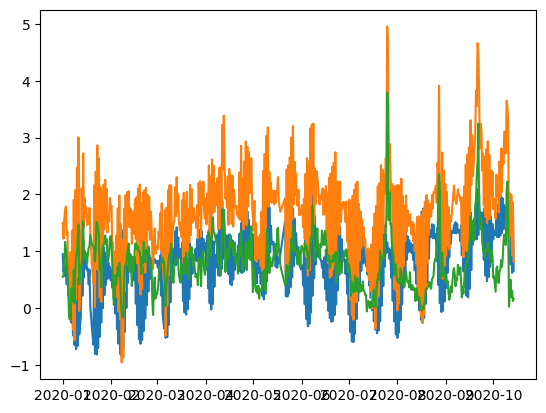

In [ ]:
plt.plot(shorttest_df['Harmonic Prediction'])
plt.plot(shorttest_df['Water Level'])
plt.plot(shorttest_df['Surge'])

In [ ]:
list(range(-40,40,5))

[-40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35]

In [ ]:
%%time
rf1 = create_rf(training_features, training_labels, estimators = 1000, random_state=42, verbose=2)
testl = test_labels
testf = test_features
testl = shorttest_labels
testf = shorttest_features
predictions1 = run_rf(rf1, testf, testl)
evaluate_rf(rf1, predictions1, testl, plot=False)

rf2 = create_rf(training2_features, training2_labels, estimators = 100, random_state=42, verbose=1)
predictions2 = run_rf(rf2, testf, testl)
evaluate_rf(rf2, predictions2, testl, plot=False)


Training Features Shape: (194105, 100)
Training Labels Shape: (194105,)
Testing Features Shape: (67175, 100)
Testing Labels Shape: (67175,)
Average baseline error:  0.62


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.


building tree 1 of 1000
building tree 2 of 1000
building tree 3 of 1000
building tree 4 of 1000
building tree 5 of 1000
building tree 6 of 1000
building tree 7 of 1000
building tree 8 of 1000
building tree 9 of 1000
building tree 10 of 1000
building tree 11 of 1000
building tree 12 of 1000
building tree 13 of 1000
building tree 14 of 1000
building tree 15 of 1000
building tree 16 of 1000
building tree 17 of 1000
building tree 18 of 1000
building tree 19 of 1000
building tree 20 of 1000
building tree 21 of 1000
building tree 22 of 1000
building tree 23 of 1000
building tree 24 of 1000
building tree 25 of 1000



KeyboardInterrupt



In [ ]:
rf1

In [ ]:
len(predictions2)

562

In [ ]:
shorttest_df

,Air Temperature,Water Level,Water Level Sigma,Wind Speed,Wind Direction,Wind Gust,Harmonic Prediction,Error,1hr Water Level,2hr Water Level,...,3hr Onshore sq Wind Force,4hr Onshore sq Wind Force,5hr Onshore sq Wind Force,6hr Onshore sq Wind Force,7hr Onshore sq Wind Force,8hr Onshore sq Wind Force,9hr Onshore sq Wind Force,10hr Onshore sq Wind Force,11hr Onshore sq Wind Force,12hr Onshore sq Wind Force
2020-01-01 00:00:00,59.0,1.499,0.197,12.44,30.0,15.94,0.950,0.549,14.505,26.976,...,417.654558,549.300426,629.819798,673.073069,756.068756,914.753425,750.994769,472.188676,406.018571,405.230987
2020-01-01 12:00:00,63.9,1.220,0.161,12.83,80.0,17.30,0.634,0.586,12.595,25.610,...,2124.956862,2949.065034,3488.554132,3435.002345,3998.246630,4661.371233,5107.188181,5538.989021,6003.443832,6168.712553
2020-01-02 00:00:00,61.3,1.565,0.361,0.58,272.0,3.89,0.817,0.748,14.426,26.704,...,-699.592014,-859.500958,-1147.827975,-1100.160971,-1183.599363,-1222.225264,-636.221802,29.288963,811.331475,2635.190901
2020-01-02 12:00:00,60.6,1.722,0.226,8.16,181.0,9.52,0.559,1.163,17.733,35.398,...,923.986317,1126.425585,1174.046054,1205.305126,1156.545792,888.253916,459.825786,183.670914,167.123016,149.006168
2020-01-03 00:00:00,63.1,1.785,0.367,15.16,97.0,16.72,0.734,1.051,17.483,32.976,...,2648.499913,2777.200355,3473.053491,4618.569117,6639.840430,9031.635057,10918.031796,11979.258446,12478.015925,12720.546538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-12 00:00:00,80.6,1.266,0.302,16.13,126.0,18.66,0.766,0.500,11.388,21.779,...,7650.797282,9774.115639,11415.219463,12671.341065,13853.709532,15312.598496,16754.004466,18431.779717,20272.203400,21914.183200
2020-10-12 12:00:00,79.0,1.991,0.266,9.14,162.0,10.50,1.801,0.190,20.443,42.480,...,3247.814736,4891.784662,7095.207556,9862.690444,12514.381271,15210.016689,17495.161273,20433.077970,23407.290171,26098.358627
2020-10-13 00:00:00,81.1,0.925,0.217,11.86,94.0,13.61,0.619,0.306,8.816,16.837,...,3514.184457,4383.383960,5013.037094,5425.001366,6298.898850,6841.052746,7410.340447,8169.983284,9165.395210,10099.293593
2020-10-13 12:00:00,77.0,1.857,0.184,7.58,350.0,9.52,1.733,0.124,19.141,39.309,...,-460.446645,-76.475467,245.368260,631.706862,1060.717356,1431.356354,1824.970426,2195.778453,2676.723439,3672.191845


In [ ]:
shortpredictions1=rf1.predict(shorttest_features)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 317 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 600 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 1000 out of 1000 | elapsed:    0.1s finished


In [ ]:
# Persistance1Predictions = np.array(shortdf['Water Level'])
# shorttest_harmonic_predictions = np.array(shorttest_df['Harmonic Prediction'])

print('Harmonic', evaluate_rf(None, np.array(shorttest_df['Harmonic Prediction']), shorttest_labels, plot=False))
print('Persistance', evaluate_rf(None, np.array(shorttest_df['Surge']+shorttest_df['Harmonic Prediction']), shorttest_labels, plot=False))
print('Persistance 1', evaluate_rf(None, np.array(shorttest_df['Water Level']), shorttest_labels, plot=False))
print('RF 1000 trees', evaluate_rf(rf1, predictions1, shorttest_labels, plot=False))
table = [['Harmonic']+ list(evaluate_rf(None, np.array(shorttest_df['Harmonic Prediction']), shorttest_labels, plot=False)),
               ['Persistance']+ list(evaluate_rf(None, np.array(shorttest_df['Surge']+shorttest_df['Harmonic Prediction']), shorttest_labels, plot=False)),
               ['Persistance 1']+ list(evaluate_rf(None, np.array(shorttest_df['Water Level']), shorttest_labels, plot=False)),
               ['RF 100 trees']+ list(evaluate_rf(rf2, predictions2, shorttest_labels, plot=False)),
               ['RF 1000 trees']+ list(evaluate_rf(rf1, predictions1, shorttest_labels, plot=False))]
print(tabulate(table, headers=['Model', 'CF15', 'MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'], tablefmt="fancy"))
display(HTML(tabulate(table, headers=['Model', 'CF15', 'MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'], tablefmt="html")))

Harmonic (0.2526690391459075, 0.8661225818505337, 0.9306570699514046, -0.27746990599841936, 0.8022829181494663, 0.7800000000000002, 3.649, 0.48857874715749217)
Persistance (0.8202846975088968, 0.19068890925266904, 0.4366794124442656, 0.7187472673238924, 0.30710498220640575, 0.22900000000000004, 2.503, 0.43667390102373393)
Persistance 1 (0.8202846975088968, 0.19068890925266907, 0.43667941244426567, 0.7187472673238924, 0.30710498220640575, 0.22900000000000004, 2.503, 0.43667390102373393)
RF 1000 trees (0.9092526690391459, 0.12846214161741287, 0.3584161570261766, 0.8105273740516884, 0.23980948754448403, 0.1675579999999991, 2.916524000000001, 0.35730945280371734)
Model              CF15       MSE      RMSE         R2       MAE     MedAE    MaxErr    residual std
-------------  --------  --------  --------  ---------  --------  --------  --------  --------------
Harmonic       0.252669  0.866123  0.930657  -0.27747   0.802283  0.78       3.649          0.488579
Persistance    0.820285  0.19

Model,CF15,MSE,RMSE,R2,MAE,MedAE,MaxErr,residual std
Harmonic,0.252669,0.866123,0.930657,-0.27747,0.802283,0.78,3.649,0.488579
Persistance,0.820285,0.190689,0.436679,0.718747,0.307105,0.229,2.503,0.436674
Persistance 1,0.820285,0.190689,0.436679,0.718747,0.307105,0.229,2.503,0.436674
RF 100 trees,0.900356,0.133139,0.364882,0.80363,0.244594,0.183955,2.8202,0.362103
RF 1000 trees,0.909253,0.128462,0.358416,0.810527,0.239809,0.167558,2.91652,0.357309


In [ ]:

features_to_use = ['Water Level', '1hr Onshore sq Wind Force']
X = np.array(training_df[features_to_use])
reg = LinearRegression(n_jobs=-1).fit(X, training_labels)
# print('linear regression - score:', reg.score(X, training_labels), ' coef:', reg.coef_, ' intercept:', reg.intercept_)
print('Linear regression 1hr', evaluate_rf(None, reg.predict(np.array(shorttest_df[features_to_use])), shorttest_labels, plot=False))

features_to_use = ['Water Level', '2hr Onshore sq Wind Force']
X = np.array(training_df[features_to_use])
reg = LinearRegression(n_jobs=-1).fit(X, training_labels)
# print('linear regression - score:', reg.score(X, training_labels), ' coef:', reg.coef_, ' intercept:', reg.intercept_)
print('Linear regression 2hr', evaluate_rf(None, reg.predict(np.array(shorttest_df[features_to_use])), shorttest_labels, plot=False))

features_to_use = ['Water Level', '3hr Onshore sq Wind Force']
X = np.array(training_df[features_to_use])
reg = LinearRegression(n_jobs=-1).fit(X, training_labels)
# print('linear regression - score:', reg.score(X, training_labels), ' coef:', reg.coef_, ' intercept:', reg.intercept_)
print('Linear regression 3hr', evaluate_rf(None, reg.predict(np.array(shorttest_df[features_to_use])), shorttest_labels, plot=False))

AllResults = []
AllResults.append(run_a_regressor(['Water Level', 'Harmonic Prediction','24hr Harmonic prediction'], training_df))
AllResults.append(run_a_regressor(['Water Level', 'Surge', 'Harmonic Prediction','24hr Harmonic prediction'], training_df))

AllResults.append(run_a_regressor(['Water Level', '1hr Onshore Wind Force'], training_df))
AllResults.append(run_a_regressor(['Water Level', 'Harmonic Prediction','24hr Harmonic prediction', 'Prior Lunar Day WL', 'Prior Lunar Day Harmonic Prediction'], training_df))
AllResults.append(run_a_regressor(['Water Level', 'Harmonic Prediction','24hr Harmonic prediction', 'Prior Lunar Half Day WL', 'Prior Lunar Half Day Harmonic Prediction', 'Prior Lunar Day WL', 'Prior Lunar Day Harmonic Prediction'], training_df))


AllResults.append(run_a_regressor(['Water Level', 'Prior Lunar Day WL', 'Prior Lunar Day WS', '1hr Onshore Wind Force'], training_df))
AllResults.append(run_a_regressor(['Water Level', 'Prior Lunar Day WL', 'Prior Lunar Day WS', '1hr Alongshore Wind Force'], training_df))
AllResults.append(run_a_regressor(['Water Level', 'Prior Lunar Day WL', 'Prior Lunar Day WS', '1hr Onshore Wind Force', '1hr Alongshore Wind Force'], training_df))

AllResults.append(run_a_regressor(['Water Level', 'Prior Lunar Day WL', 'Prior Lunar Day WS', 'Predicted Onshore Wind Force in 24hr','1hr Alongshore Wind Force'], training_df))

#        'Predicted Wind Dirrection in 24hr','Predicted Wind Speed in 24hr',


# training2_df = load_file('BHPtrainingSet2.zip')
AllResults.append(run_a_regressor(['Water Level', 'Harmonic Prediction','24hr Harmonic prediction'], training2_df))
AllResults.append(run_a_regressor(['Water Level', 'Surge', 'Harmonic Prediction','24hr Harmonic prediction'], training2_df))

display(HTML(tabulate(AllResults, headers=['features','CF15', 'MSE','RMSE',  'R2', 'MAE', 'MedAE', 'MaxErr', 'residual std'], tablefmt="html")))

Linear regression 1hr (0.8362989323843416, 0.17809526604479778, 0.4220133481832035, 0.7373220055215316, 0.30245592332521903, 0.23247205233116353, 2.466511723485209, 0.4218477719084869)
Linear regression 2hr (0.8362989323843416, 0.17783570280191385, 0.4217057063900296, 0.7377048430533497, 0.3022282926238018, 0.23060274077639098, 2.4639426830731446, 0.42154345287523715)
Linear regression 3hr (0.8398576512455516, 0.17767671445398153, 0.4215171579591767, 0.7379393396871333, 0.3021254026785616, 0.23312622466926514, 2.462777742923454, 0.4213568150772532)


features,CF15,MSE,RMSE,R2,MAE,MedAE,MaxErr,residual std
"Water Level, Harmonic Prediction, 24hr Harmonic prediction",0.898577,0.12848,0.358441,0.810501,0.243163,0.176202,2.67276,0.353571
"Water Level, Error, Harmonic Prediction, 24hr Harmonic prediction",0.898577,0.128475,0.358435,0.810508,0.243174,0.176067,2.67334,0.353549
"Water Level, 1hr Onshore Wind Force",0.836299,0.177421,0.421214,0.738316,0.302015,0.231307,2.48033,0.421043
"Water Level, Harmonic Prediction, 24hr Harmonic prediction, Prior Lunar Day WL, Prior Lunar Day Harmonic Prediction",0.898577,0.12848,0.35844,0.810502,0.243165,0.17609,2.67291,0.353568
"Water Level, Harmonic Prediction, 24hr Harmonic prediction, Prior Lunar Half Day WL, Prior Lunar Half Day Harmonic Prediction, Prior Lunar Day WL, Prior Lunar Day Harmonic Prediction",0.902135,0.128108,0.357922,0.811049,0.242295,0.170509,2.66725,0.353067
"Water Level, Prior Lunar Day WL, Prior Lunar Day WS, 1hr Onshore Wind Force",0.83452,0.177814,0.42168,0.737737,0.301343,0.230768,2.45931,0.42145
"Water Level, Prior Lunar Day WL, Prior Lunar Day WS, 1hr Alongshore Wind Force",0.836299,0.176741,0.420405,0.73932,0.300985,0.230722,2.45381,0.420144
"Water Level, Prior Lunar Day WL, Prior Lunar Day WS, 1hr Onshore Wind Force, 1hr Alongshore Wind Force",0.829181,0.17622,0.419786,0.740088,0.302415,0.236447,2.54126,0.419732
"Water Level, Prior Lunar Day WL, Prior Lunar Day WS, Predicted Onshore Wind Force in 24hr, 1hr Alongshore Wind Force",0.822064,0.180222,0.424526,0.734185,0.303018,0.235963,2.5909,0.424415
"Water Level, Harmonic Prediction, 24hr Harmonic prediction",0.882562,0.138174,0.371718,0.796203,0.255779,0.184949,2.71613,0.35497


In [ ]:
(y_true, y_pred)

In [ ]:

find_best_features_r2(training_df, title='Optimize R2 for 2017-2019')
find_best_features_r2(training2_df, title='Optimize R2 for 1996-2019')
find_best_features_MSE(training_df, title='Optimize MSE for 2017-2019')
find_best_features_MSE(training2_df, title='Optimize MSE for 1996-2019')
find_best_features_MSE_r2(training_df, title='Optimize MSE and R2 for 2017-2019')
find_best_features_MSE_r2(training2_df, title='Optimize MSE and R2 for 1996-2019')

In [ ]:
%%time
# df = WLP.load_file('BHPAllData.zip')
print('data loaded')
df2=df.reindex(pd.date_range('01-01-2017','12-31-2019 23:54',freq='6min'))
print('data reduced')
newdf = WLP.clean_data1(WLP.add_features(df2)).dropna()                 # 33 mins or so
print('new features added')
find_best_features_r2(newdf, title='Optimize R2 for 2017-2019')
find_best_features_MSE(newdf, title='Optimize MSE for 2017-2019')
find_best_features_MSE_r2(newdf, title='Optimize MSE and R2 for 2017-2019')

In [ ]:
%%time
df = WLP.load_file('BHPAllData.zip')
print('data loaded')
df2=df.reindex(pd.date_range('01-01-2017','12-31-2019 23:54',freq='6min'))
df3 = df2.resample('1h', label='right', closed='right').mean()
print('data reduced')
badcols=['Prior Lunar Day WL','Prior Lunar Half Day WL','Prior Lunar Day WS',
         'Prior Lunar Half Day WS','Prior Lunar Day Harmonic Prediction','Prior Lunar Half Day Harmonic Prediction']
#newdf2 = WLP.clean_data1(WLP.add_features(df3).drop(columns=badcols)).dropna()                 # 33 mins or so
newdf2 = WLP.clean_data1(add_predictions(add_wind_force(add_96hr_water_levels(WLP.add_features(df3).drop(columns=badcols)),how_far=96))).dropna()                 # 33 mins or so

#shorttest_df=WLP.clean_data1(df.reindex(pd.date_range('01-01-2020','10-15-2020',freq='12H'))[whichfeatures]).dropna()

test_df=add_predictions(add_wind_force(add_96hr_water_levels(WLP.add_features(WLP.clean_data1(df.reindex(pd.date_range('01-01-2020','10-15-2020',freq='6min')))).drop(columns=badcols)),how_far=96))
shorttest_df=test_df.reindex(pd.date_range('01-01-2020','10-15-2020',freq='12H'))

print('new features added')
find_best_features_r2(newdf2, shorttest_df, title='Optimize R2 for 2017-2019', delta=.0001, max_features=25)
find_best_features_MSE(newdf2, shorttest_df, title='Optimize MSE for 2017-2019', delta=.0001, max_features=25)
find_best_features_MSE_r2(newdf2, shorttest_df, title='Optimize MSE and R2 for 2017-2019', delta=.0001, max_features=25)

In [ ]:
%%time
find_best_features_r2(newdf2, shorttest_df, title='Optimize R2 for 2017-2019', delta=.0001, max_features=25)
find_best_features_MSE(newdf2, shorttest_df, title='Optimize MSE for 2017-2019', delta=.0001, max_features=25)
find_best_features_MSE_r2(newdf2, shorttest_df, title='Optimize MSE and R2 for 2017-2019', delta=.0001, max_features=25)

In [ ]:
for k in df3.keys():
    print(k,df3[k].isna().sum())

In [ ]:
training2_df = load_file('BHPtrainingSet2.zip')
training2_labels = np.array(training2_df['Target'])
training2_features = np.array(training2_df.drop('Target', axis = 1))

In [ ]:

rf1_2 = create_rf(training2_features, training2_labels, estimators = 1000, random_state=42, verbose=10)
predictions1_2 = run_rf(rf1_2, test_features, test_labels)
evaluate_rf(rf1, predictions1_2, test_labels, plot=False)

rf2_2 = create_rf(training2_features, training2_labels, estimators = 100, random_state=42, verbose=10)
predictions2_2 = run_rf(rf2_2, test_features, test_labels)
evaluate_rf(rf2_2, predictions2_2, test_labels, plot=False)

In [ ]:
rf1

In [ ]:
evaluate_rf(rf2, predictions2, test_labels)

In [ ]:
len(predictions)

In [ ]:
rf2 = RandomForestRegressor(n_estimators = 100, random_state = 42,verbose=10,n_jobs=-1)
rf2.fit(training_features, training_labels);

In [ ]:
# Use the forest's predict method on the test data
predictions = rf.predict(test_features)
# Calculate the absolute errors
errors = abs(predictions - test_labels)
# Print out the mean absolute error (mae)
print('Mean Absolute Error:', round(np.mean(errors), 2), 'degrees.')

In [ ]:

plot_results(predictions,test_labels,errors)
# plot_results(test_df[''])

In [ ]:
training_df.loc[target_indices]['Water Level']

In [ ]:
for date in training_df.index:
    print(date, 'target date', date+ timedelta(days=1), ' target:', training_df['Water Level'].get(date+ timedelta(days=1), None))

In [ ]:
test_df['Water Level']

In [ ]:
training_df['Target'] = [training_df['Water Level'].get(date+ timedelta(days=1), None)for date in training_df.index]

In [ ]:
pdf.keys()

In [ ]:
pdf = df = load_file('BHPPredictions.zip')
name=' Prediction\n'
fig, ax = plt.subplots(1, 1,figsize=(14, 3.5),  sharey=True)
fig.suptitle('Periodogram')

ax.set_title('Prediction')
ax.set_xlabel('Hz')
f, Pxx_den = signal.periodogram(pdf[name], fs=240)
ax.semilogy(f, Pxx_den)
ax.set_xlim(0, 5)
ax.set_ylabel('PSD [V**2/Hz]')
plt.show()

fig, axes = plt.subplots(1, 1,figsize=(14, 3.5),  sharey=True)
fig.suptitle('Welch Periodogram')

ax.set_title(name)
ax.set_xlabel('Hz')
f, Pxx_den = signal.welch(pdf[name], fs=240, scaling='spectrum', window='bartlett')
ax.semilogy(f, np.sqrt(Pxx_den), label='mean')
# ax.set_xlim(0, 10)

ax.set_ylabel('Linear spectrum [V RMS]')
plt.show()

fig, axes = plt.subplots(1, 1,figsize=(14, 3.5),  sharey=True)
fig.suptitle('Welch Periodogram')

ax.set_title(name)
ax.set_xlabel('Hz')
f, Pxx_den = signal.welch(pdf[name], fs=240, scaling='spectrum', window='bartlett')
ax.semilogy(f, Pxx_den, label='mean')
# ax.set_xlim(0, 10)

ax.set_ylabel('Linear spectrum [V RMS]')
plt.show()

In [ ]:
# sns.pairplot(df)
# comparison_plot(df)

In [ ]:
plot_df(df)

In [ ]:
sns.distplot(df['Water Level'])


In [ ]:
# g = sns.PairGrid(df)
# g.map_upper(sns.scatterplot)
# g.map_lower(sns.kdeplot)
# g.map_diag(sns.kdeplot, lw=3, legend=False)

In [ ]:
# g = sns.PairGrid(df)
# g.map(sns.regplot, color=".3")
# # g.set(ylim=(-1, 11), yticks=[0, 5, 10])

In [ ]:
dfm = df.melt()


In [ ]:
dfm

In [ ]:
g=sns.FacetGrid(dfm, col="variable", sharey=False)
g.map(plt.plot, 'value')

In [ ]:
# g = sns.PairGrid(df)
# g.map_lower(correlation_values)
# g.map_diag(sns.distplot, bins=20, kde=False, sharey=False) #, line_kws={'color':'r'})
# g.map_upper(sns.scatterplot)


# plt.show()

In [ ]:
g = sns.PairGrid(df)
plt.show()

In [ ]:
df.plot( kind='line', subplots=True, figsize=(16,12))
df.plot( kind='hist', subplots=True, figsize=(16,12),sharex=False, sharey=True, bins=40)

In [ ]:
comparison_plot(shortdf)


In [ ]:
dfm = df.melt()
g=sns.FacetGrid(dfm, col="variable", sharey=False)
g.map(plt.plot, 'value')
plt.show()
g=sns.FacetGrid(dfm, col="variable", sharey=False)
g.map(plt.hist, 'value')
plt.show()


In [ ]:
fig = plt.figure(figsize=(16,5))
plt.plot(df['Prediction'], label='Prediction')
plt.plot(df['Water Level'], label='Water Level')
plt.legend()
plt.show()

In [ ]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()

In [ ]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True,  bins=10,edgecolor='white', nsector=36)
ax.set_legend()

In [ ]:


fig = plt.figure(figsize=(14, 7))
rect=[0.5,0.5,0.4,0.4]
# fig.suptitle('Windroses')

wa = WindroseAxes(fig,rect)
fig.add_axes(wa)
wa.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True, opening=0.8, edgecolor='white')
wa.set_legend()

ax2 = WindroseAxes(fig, [0.6,0.6,0.3,0.3])
ax2.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True,  bins=10,edgecolor='white', nsector=36)
fig.add_axes(ax2)
plt.show()
#ax2.set_legend()

In [ ]:
fig = plt.figure(figsize=(14, 7),linewidth=10, edgecolor="#04253a")
rect=[0.5,0.5,0.4,0.4]
# fig.suptitle('Windroses')

wa = WindroseAxes(fig,rect)
fig.add_axes(wa)
wa.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True, opening=0.8, edgecolor='white')
wa.set_legend()

ax2 = WindroseAxes(fig, [0.1,0.1,0.3,0.3])
ax2.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True,  bins=10,edgecolor='white', nsector=36)
fig.add_axes(ax2)
plt.show()
#ax2.set_legend()

In [ ]:
fig = plt.figure(figsize=(14, 7),linewidth=10, edgecolor="#04253a")
rect=[0.5,0.5,0.4,0.4]
# fig.suptitle('Windroses')

wa = WindroseAxes(fig,rect)
fig.add_axes(wa)
wa.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True, opening=0.8, edgecolor='white')
wa.set_legend()

ax2 = WindroseAxes(fig, [0.1,0.1,0.5,0.3])
ax2.bar(df1['Wind Direction'], df1['Wind Speed'], normed=True,  bins=10,edgecolor='white', nsector=36)
fig.add_axes(ax2)
plt.show()
#ax2.set_legend()

In [ ]:

def show_windrose(df, title=None, nsec=36):
    fig = plt.figure(figsize=(16,4))
    fig.suptitle(title)
    ax = fig.add_subplot(1, 3, 1, projection='windrose')
    ax.contourf(df['Wind Direction'], df['Wind Speed'], bins=10,nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Wind Speed", labelspacing=.05)
    ax = fig.add_subplot(1, 3, 2, projection='windrose')
    ax.contourf(df['Wind Direction'], df['Surge'], bins=10, nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Surge", labelspacing=.1)
    ax = fig.add_subplot(1, 3, 3, projection='windrose')
#     ax.contour(df['Wind Direction'], df['Onshore Wind Force'],  colors='black', bins=10)
    ax.contourf(df['Wind Direction'], df['Onshore Wind Force'],  nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Onshore Wind Force", labelspacing=.1)
    plt.show()


def show_windrose2(df, title=None, nsec=32):
    fig = plt.figure(figsize=(16,4))
    fig.suptitle(title)
    ax = fig.add_subplot(1, 3, 1, projection='windrose')
    ax.contourf(df['Wind Direction'], df['Wind Speed'], bins=10,nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Wind Speed", labelspacing=.05)
    ax = fig.add_subplot(1, 3, 2, projection='windrose')
    ax.contourf(df['Wind Direction'], df['Surge'], bins=10, nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Surge", labelspacing=.1)
    ax = fig.add_subplot(1, 3, 3, projection='windrose')
#     ax.contour(df['Wind Direction'], df['Onshore Wind Force'],  colors='black', bins=10)
    ax.contourf(df['Wind Direction'], df['Alongshore Wind Force'],  nsector=nsec, normed=True)
    plt.legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0., fontsize="small", title="Alongshore Wind Force", labelspacing=.1)
    plt.show()

show_windrose(training_df, title='2017-2019')
show_windrose2(training_df, title='2017-2019')
show_windrose(test_df, title='2020')
show_windrose(training2_df, title='2007-2016')
show_windrose(training2_df, title='2007-2016',nsec=16)
show_windrose(training2_df, title='2007-2016',nsec=12)
show_windrose(training2_df, title='2007-2016',nsec=8)

In [ ]:
plt.figure(figsize=(17,5))
plt.plot(test_df['Alongshore Wind Force'], label='Alongshore')
plt.plot(test_df['Onshore Wind Force'], label='Onshore')
plt.legend()
ax2 = plt.gca().twinx()
ax2.plot(test_df['Wind Direction'], color='red', label='Wind Direction')
plt.legend()
plt.show()

In [ ]:
training2_df

In [ ]:


showCorrelations(shortdf, annot=False, big=True)


In [ ]:
df

In [ ]:
df['Surge'] = df['Water Level']-df['Prediction']

In [ ]:
df

In [ ]:
plt.plot(df['Surge'])

In [ ]:
y_true = np.array([1,  1.2,1.3,1.1,1,1,1.1])
y_pred = np.array([1.1, 1.3, 1.4, .9, .8, 1.01, 1])
MSE = metrics.mean_squared_error(y_true, y_pred)
RMSE = math.sqrt(MSE)
R2 = metrics.r2_score(y_true, y_pred)
Std = np.std(y_true-y_pred)
print(MSE, RMSE, R2,Std)
y_true = y_true * 3.28084
y_pred *= 3.28084
MSE2 = metrics.mean_squared_error(y_true, y_pred)
RMSE2 = math.sqrt(MSE2)
R22 = metrics.r2_score(y_true, y_pred)
Std2 = np.std(y_true-y_pred)
print(MSE2, RMSE2, R22, Std2)
print(MSE2/MSE, RMSE2/RMSE, R22/R2, Std2/Std)


In [ ]:
tdf = pd.DataFrame(columns=['a','b'])
tdf.loc['fred'] = [31,33]
tdf

In [ ]:
%%timeit [training_df['Water Level'].get(date+ timedelta(days=1), None)for date in training_df.index]



In [ ]:
import random
y = [random.uniform(3,8) for i in range(30)]
p = [random.uniform(3,8) for i in range(30)]


In [ ]:
import time
# rf1   1000 trees
# rf2   100  trees
start_time = time.time()
importances = rf1.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf1.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 4.712 seconds


Text(0, 0.5, 'Mean decrease in impurity')

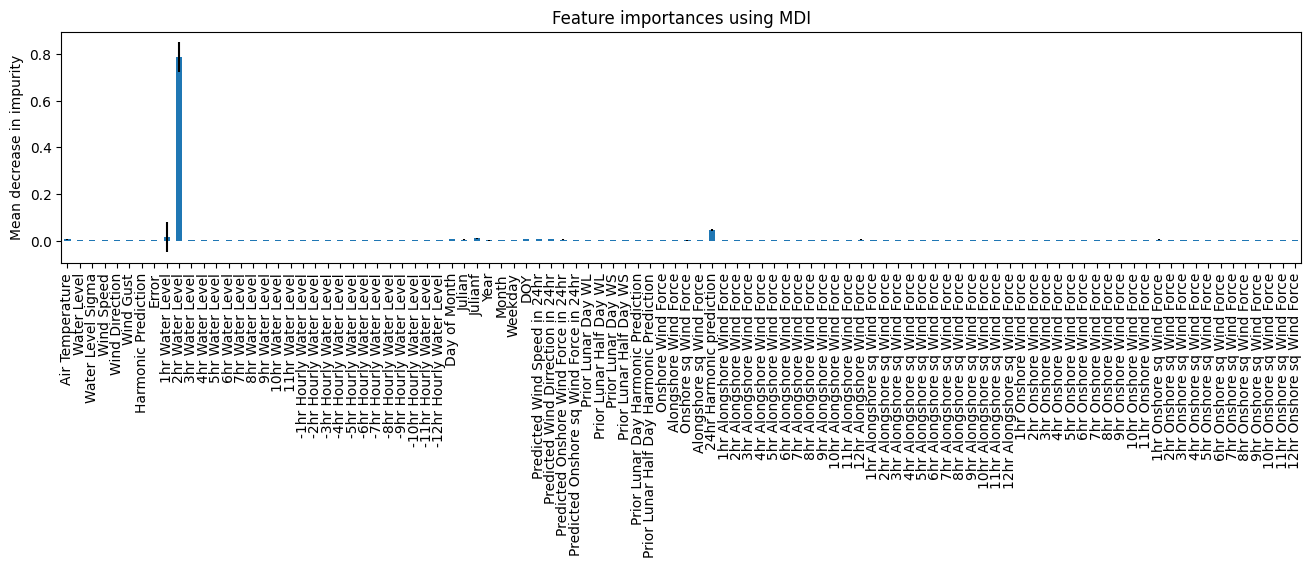

In [ ]:
#training_features = np.array(training_df.drop('Target', axis = 1))
#training2_features = np.array(training2_df.drop('Target', axis = 1))
features = list(training_df.columns)
features.remove('Target')
features

forest_importances = pd.Series(importances, index=features)

fig, ax = plt.subplots(figsize=(16,3))

forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
#fig.tight_layout()

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.3s finished


Elapsed time to compute the importances: 425.555 seconds


C:\Users\Scott\AppData\Local\Temp\ipykernel_30356\68806351.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


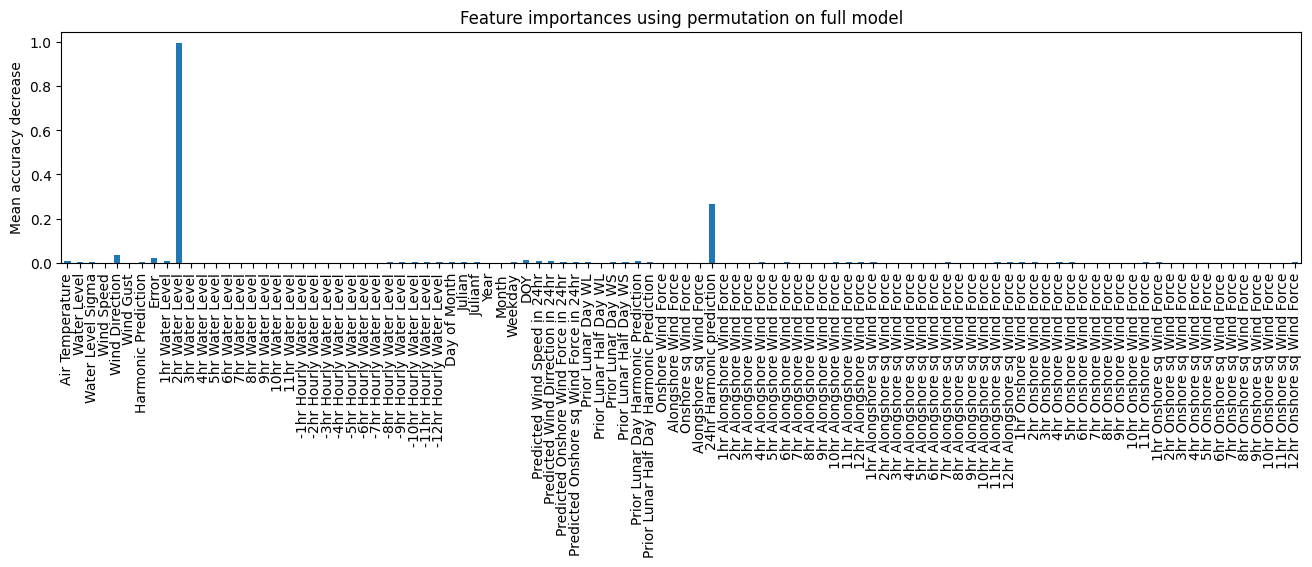

In [ ]:
from sklearn.inspection import permutation_importance

def RFImportance(rf, X, Y):
    start_time = time.time()
    result = permutation_importance(rf, X, Y, n_repeats=10, random_state=42, n_jobs=2)
    elapsed_time = time.time() - start_time
    print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

    forest_importances = pd.Series(result.importances_mean, index=features)
    return (forest_importances, result)

#RFImportance(rf1, training_features, training_labels)
(forest_importances, result) = RFImportance(rf2, training_features, training_labels)

fig, ax = plt.subplots(figsize=(16,3))
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()


C:\Users\Scott\AppData\Local\Temp\ipykernel_30356\3418736666.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


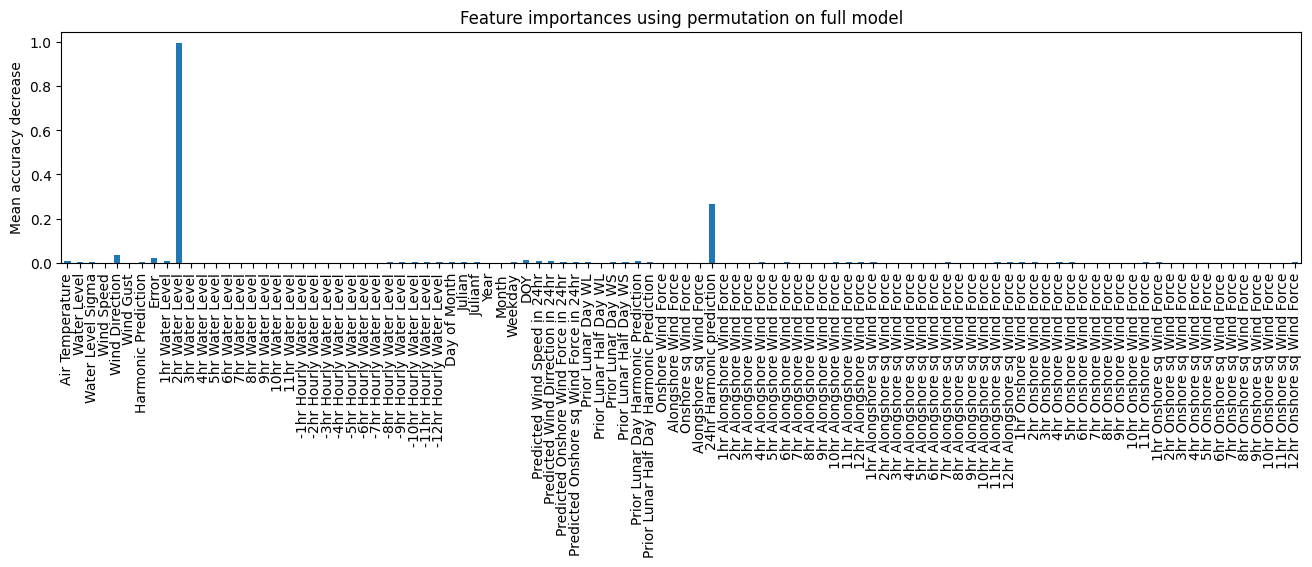

In [ ]:
fig, ax = plt.subplots(figsize=(16,3))
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [ ]:


import lime
import lime.lime_tabular



In [ ]:
feature_names = features

predict_fn_rf = lambda x: random_forest.predict_proba(x).astype(float)
explainer = lime.lime_tabular.LimeTabularExplainer(training_features,
        feature_names = feature_names,class_names=['Will Die','Will Survive'],kernel_width=5)

In [ ]:
choosen_instance = X_test.loc[[421]].values[0]
exp = explainer.explain_instance(choosen_instance, predict_fn_rf,num_features=10)
exp.show_in_notebook(show_all=False)